In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
df = pd.read_csv('airbnb.csv')
print(df.head())

   index   room_id   host_id     room_type  country  city  neighborhood  \
0      0   7556928  39610649  Private room      NaN   NaN           NaN   
1      1    769573   4059836  Private room      NaN   NaN           NaN   
2      2   9032306  29003311  Private room      NaN   NaN           NaN   
3      3  16828729  54497897  Private room      NaN   NaN           NaN   
4      4   2671579  13676129  Private room      NaN   NaN           NaN   

                                             address  reviews  \
0  Buenos Aires, Ciudad Autonoma de Buenos Aires,...        1   
1  Buenos Aires, Autonomous City of Buenos Aires,...        0   
2  Buenos Aires, Ciudad Autónoma de Buenos Aires,...        0   
3                      Buenos Aires, CABA, Argentina        5   
4       Lanús Este, Buenos Aires Province, Argentina        0   

   overall_satisfaction  ...   latitude  longitude  survey_id  \
0                   NaN  ... -34.557034 -58.479179          1   
1                   NaN  ...

In [4]:
df=df.drop(['country','city','neighborhood','minstay','coworker_hosted','extra_host_languages'],axis=1)

In [5]:
df["overall_satisfaction"]=df["overall_satisfaction"].fillna(df["overall_satisfaction"].mean())

In [6]:
df["bedrooms"]=df["bedrooms"].fillna(df["bedrooms"].mean())

In [7]:
df["bathrooms"]=df["bathrooms"].fillna(df["bathrooms"].mean())

In [8]:
df["name"]=df["name"].fillna(df["name"].mode()[0])

In [9]:
df["overall_satisfaction"] = df["overall_satisfaction"].map(lambda x: 1 if x == 5 else 0)

In [10]:
df = df.drop("name",axis=1)

In [11]:
df.describe()

,index,room_id,host_id,reviews,overall_satisfaction,accommodates,bedrooms,bathrooms,price,deleted,latitude,longitude,survey_id
count,10116.000000,1.011600e+04,1.011600e+04,10116.000000,10116.000000,10116.000000,10116.000000,10116.000000,10116.000000,10116.0,10116.000000,10116.000000,10116.0
mean,5057.500000,1.285720e+07,4.801712e+07,13.862100,0.306445,2.758205,1.144301,1.276413,1199.468367,0.0,-34.592824,-58.415531,1.0
std,2920.381996,7.504733e+06,4.983494e+07,27.125935,0.461040,1.607157,1.136893,0.826091,1443.032948,0.0,0.018841,0.029438,0.0
min,0.000000,7.270000e+03,2.616000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,-34.700462,-58.530268,1.0
25%,2528.750000,5.701972e+06,6.715024e+06,0.000000,0.000000,2.000000,1.000000,1.000000,525.000000,0.0,-34.604137,-58.434410,1.0
50%,5057.500000,1.409356e+07,2.725928e+07,3.000000,0.000000,2.000000,1.000000,1.000000,897.000000,0.0,-34.591820,-58.415608,1.0
75%,7586.250000,1.987696e+07,7.887792e+07,15.000000,1.000000,4.000000,1.000000,1.276413,1345.000000,0.0,-34.582302,-58.392005,1.0
max,10115.000000,2.321917e+07,1.726363e+08,360.000000,1.000000,16.000000,50.000000,45.000000,30570.000000,0.0,-34.526739,-58.347903,1.0


In [12]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10116 entries, 0 to 10115
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 10116 non-null  int64  
 1   room_id               10116 non-null  int64  
 2   host_id               10116 non-null  int64  
 3   room_type             10116 non-null  object 
 4   address               10116 non-null  object 
 5   reviews               10116 non-null  int64  
 6   overall_satisfaction  10116 non-null  int64  
 7   accommodates          10116 non-null  int64  
 8   bedrooms              10116 non-null  float64
 9   bathrooms             10116 non-null  float64
 10  price                 10116 non-null  float64
 11  deleted               10116 non-null  int64  
 12  last_modified         10116 non-null  object 
 13  latitude              10116 non-null  float64
 14  longitude             10116 non-null  float64
 15  survey_id          

In [13]:
df.tail()

,index,room_id,host_id,room_type,address,reviews,overall_satisfaction,accommodates,bedrooms,bathrooms,price,deleted,last_modified,latitude,longitude,survey_id,location,property_type,currency,rate_type
10111,10111,18841938,87705745,Entire home/apt,"Buenos Aires, Buenos Aires, Argentina",10,1,3,1.0,2.0,1648.0,0,2018-02-10T22:16:22Z,-34.610890,-58.374210,1,0101000020E610000007EBFF1CE62F4DC00ABABDA4314E...,Apartment,ARS,nightly
10112,10112,16379736,107285727,Entire home/apt,"Buenos Aires, Ciudad Autónoma de Buenos Aires,...",0,0,3,1.0,1.0,611.0,0,2018-02-10T08:01:23Z,-34.601463,-58.409904,1,0101000020E6100000F23FF9BB77344DC0856055BDFC4C...,Apartment,ARS,nightly
10113,10113,21581413,112852550,Shared room,"Palermo, Buenos Aires, Argentina",0,0,16,1.0,4.0,268.0,0,2018-02-11T04:59:24Z,-34.580961,-58.438593,1,0101000020E610000094A0BFD023384DC030A017EE5C4A...,House,ARS,nightly
10114,10114,22680496,112852550,Shared room,"Palermo, Buenos Aires, Argentina",0,0,2,1.0,3.0,268.0,0,2018-02-11T04:59:24Z,-34.581476,-58.436761,1,0101000020E61000008995D1C8E7374DC057B439CE6D4A...,House,ARS,nightly
10115,10115,17224182,115989279,Shared room,"Buenos Aires, CABA, Argentina",0,0,6,1.0,4.0,227.0,0,2018-02-11T04:59:24Z,-34.587287,-58.437512,1,0101000020E6100000C4CDA96400384DC0D82E6D382C4B...,Hostel,ARS,nightly


In [14]:
df = df.drop(['currency','rate_type','location','last_modified','address'],axis=1)

In [15]:
df["property_type"].value_counts()

property_type
Apartment              8319
House                   860
Loft                    218
Condominium             205
Other                   197
Dorm                     78
Bed &amp; Breakfast      59
Guest suite              47
Guesthouse               30
Hostel                   26
Serviced apartment       18
In-law                   16
Boutique hotel           11
Townhouse                11
Casa particular           6
Pension (Korea)           4
Boat                      3
Vacation home             2
Camper/RV                 2
Chalet                    1
Cabin                     1
Villa                     1
Timeshare                 1
Name: count, dtype: int64

In [16]:
df = df.drop("property_type",axis=1)

In [17]:
df["room_type"].value_counts()

room_type
Entire home/apt    8059
Private room       1826
Shared room         231
Name: count, dtype: int64

In [18]:
df["room_type"] = df["room_type"].map({
    "Entire home/apt": 0,
    "Private room": 1,
    "Shared room": 2})

In [19]:
df.isnull().sum()

index                   0
room_id                 0
host_id                 0
room_type               0
reviews                 0
overall_satisfaction    0
accommodates            0
bedrooms                0
bathrooms               0
price                   0
deleted                 0
latitude                0
longitude               0
survey_id               0
dtype: int64

In [20]:
print(df.isnull().sum())

index                   0
room_id                 0
host_id                 0
room_type               0
reviews                 0
overall_satisfaction    0
accommodates            0
bedrooms                0
bathrooms               0
price                   0
deleted                 0
latitude                0
longitude               0
survey_id               0
dtype: int64


In [21]:
X = df.drop("overall_satisfaction", axis=1)
y = df["overall_satisfaction"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

Accuracy: 0.708498023715415
confusion matrix: [[1333   66]
 [ 524  101]]
classification report:               precision    recall  f1-score   support

           0       0.72      0.95      0.82      1399
           1       0.60      0.16      0.26       625

    accuracy                           0.71      2024
   macro avg       0.66      0.56      0.54      2024
weighted avg       0.68      0.71      0.64      2024



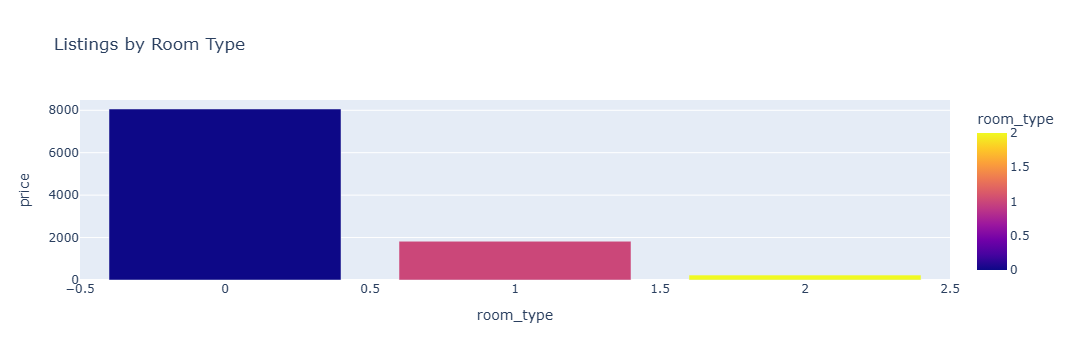

In [27]:
import plotly.express as px
import plotly.graph_objects as go
room_counts = df.groupby('room_type')['price'].count().reset_index()
fig = px.bar(room_counts, x='room_type', y='price', color='room_type', title='Listings by Room Type')
fig.show()

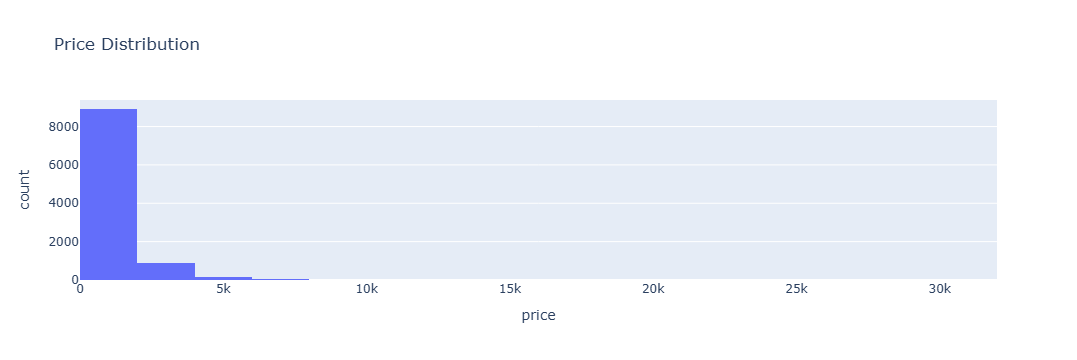

In [28]:
fig = px.histogram(df, x='price', nbins=30, title='Price Distribution')
fig.show()

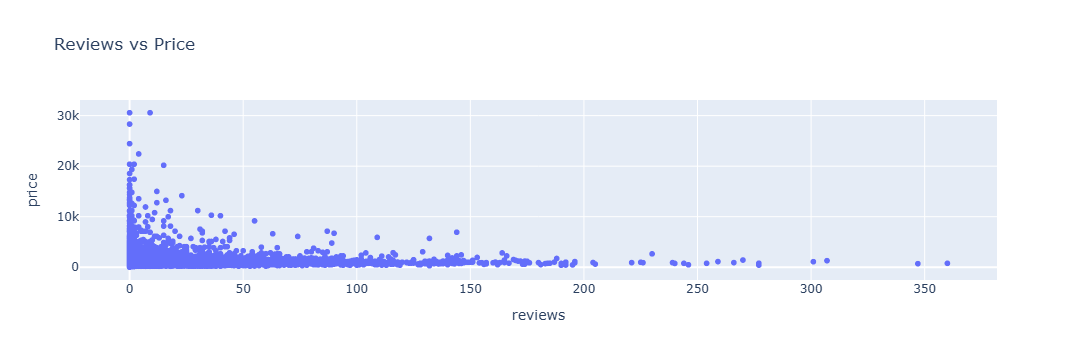

In [29]:
fig = px.scatter(df, x='reviews', y='price', title='Reviews vs Price')
fig.show()

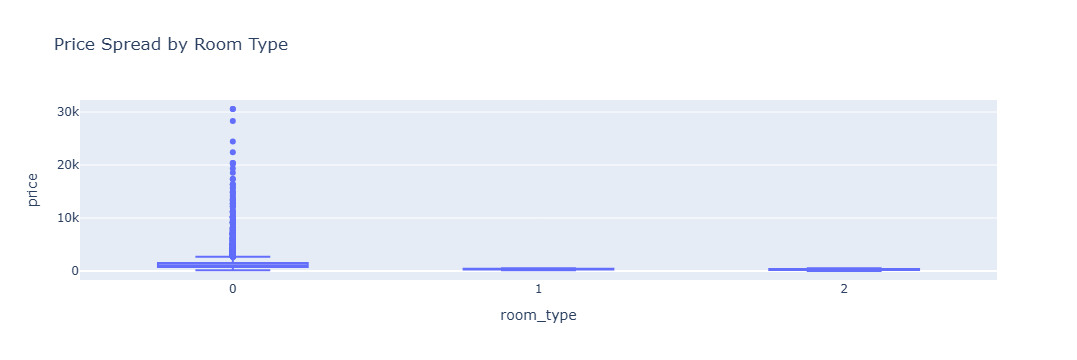

In [30]:
fig = px.box(df, x='room_type', y='price', title='Price Spread by Room Type')
fig.show()

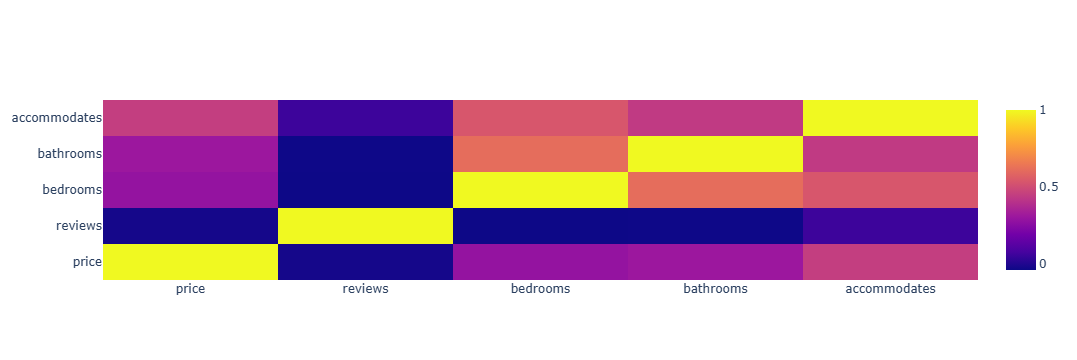

In [31]:
corr = df[['price','reviews','bedrooms','bathrooms','accommodates']].corr()
fig = go.Figure(data=go.Heatmap(z=corr.values, x=corr.columns, y=corr.columns))
fig.show()